# Exploratory Data Analysis: Student Performance

This notebook analyzes student performance using demographic, educational, and academic score features.

## Importing Libraries and Loading the Dataset

The required Python libraries are imported, and the student performance dataset is loaded for analysis.

In [50]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


## Initial Data Inspection

The dataset is inspected using `info()`, `head()`, descriptive statistics, missing-value checks, duplicate checks, and unique-value analysis.

In [51]:
df = pd.read_csv("../data/stud.csv")

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [53]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [54]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [55]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### Observation

- The dataset contains categorical and numerical features.
- The score columns are numerical variables.
- Missing values and duplicate records are checked before further analysis.
- Descriptive statistics provide an overview of the score distributions.

## Exploring Categorical Variables

The unique categories in gender, race/ethnicity, parental education, lunch type, and test preparation course are examined.

In [58]:
print("Categories in 'gender' variable:", end=" ")
print(df["gender"].unique())

print("Categories in 'race/ethnicity' variable:", end=" ")
print(df["race_ethnicity"].unique())

print("Categories in 'parental level of education' variable:", end=" ")
print(df["parental_level_of_education"].unique())   

print("Categories in 'lunch variable:", end=" ")
print(df["lunch"].unique())

print("Categories in 'test preparation course' variable:", end=" ")
print(df["test_preparation_course"].unique())

Categories in 'gender' variable: <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch variable: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable: <StringArray>
['none', 'completed']
Length: 2, dtype: str


### Observation

- The dataset contains several categorical variables that can be used to compare student performance.
- These variables will be analyzed using count plots, bar plots, and box plots.

## Identifying Numerical and Categorical Features

The columns are divided into numerical and categorical features based on their data types.

In [59]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != "O"]
categorical_features = [feature for feature in df.columns if df[feature].dtype == "O"]

print("We have {} numerical features: {}".format(len(numeric_features), numeric_features))
print("We have {} categorical features: {}".format(len(categorical_features), categorical_features))

We have 8 numerical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']
We have 0 categorical features: []


In [60]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Feature Engineering

Two new features are created:

- `Total_score`: The sum of math, reading, and writing scores.
- `Average_score`: The average of the three subject scores.

In [61]:
df["Total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["Average_score"] = df["Total_score"] / 3

In [62]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


## Identifying Extreme Scores

The number of students who achieved full marks and the number of students who scored 20 or below in each subject are calculated.

In [63]:
reading_full = df[df["reading_score"]==100]["Average_score"].count()
writing_full = df[df["writing_score"]==100]["Average_score"].count()
math_full = df[df["math_score"]==100]["Average_score"].count()

print("Number of students with full marks in reading:", reading_full)
print("Number of students with full marks in writing:", writing_full)       
print("Number of students with full marks in math:", math_full)

Number of students with full marks in reading: 17
Number of students with full marks in writing: 14
Number of students with full marks in math: 7


### Observation

- Full-score and low-score counts help identify exceptional and struggling students.
- These results can be used to understand subject-wise performance variation.

In [64]:
reading_score_20 = df[df["reading_score"] <= 20]["Average_score"].count()
writing_score_20 = df[df["writing_score"] <= 20]["Average_score"].count()
math_score_20 = df[df["math_score"] <= 20]["Average_score"].count()

print("Number of students with less than or equal to 20 marks in reading:", reading_score_20)
print("Number of students with less than or equal to 20 marks in writing:", writing_score_20)
print("Number of students with less than or equal to 20 marks in math:", math_score_20) 

Number of students with less than or equal to 20 marks in reading: 1
Number of students with less than or equal to 20 marks in writing: 3
Number of students with less than or equal to 20 marks in math: 4


## Distribution of Average Scores

Histograms are used to examine the distribution of average scores overall and across gender and race/ethnicity groups.

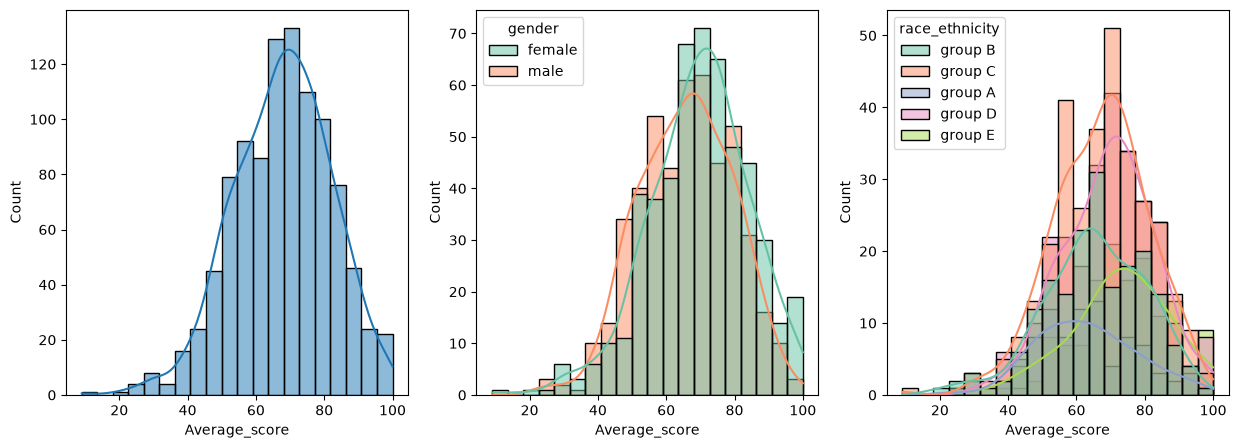

In [65]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(131)
sns.histplot(data=df, x="Average_score", bins=20, kde=True)

plt.subplot(132)
sns.histplot(data=df, x="Average_score", hue="gender", palette="Set2", kde =True, bins=20)


plt.subplot(133)
sns.histplot(data=df, x="Average_score", hue="race_ethnicity", palette="Set2", kde =True, bins=20)  
plt.show()


### Observation

- The average scores show the overall performance pattern of the students.
- The distributions across gender and race/ethnicity groups can be compared visually.
- Any differences between groups should be interpreted as associations, not causal relationships.

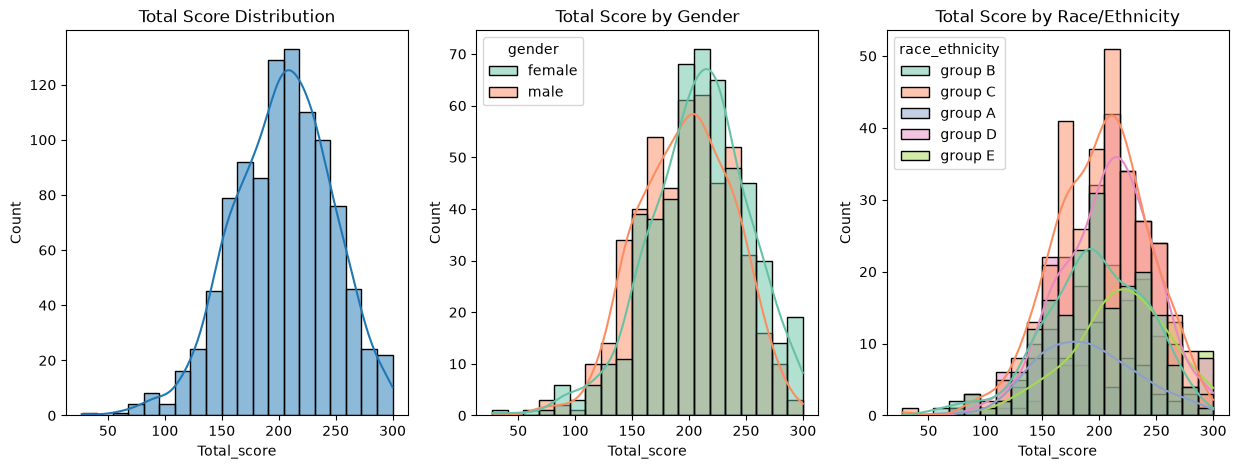

In [66]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(131)
sns.histplot(data=df, x="Total_score", bins=20, kde=True)
plt.title("Total Score Distribution")

plt.subplot(132)
sns.histplot(data=df, x="Total_score", hue="gender", palette="Set2", kde =True, bins=20)
plt.title("Total Score by Gender")

plt.subplot(133)
sns.histplot(data=df, x="Total_score", hue="race_ethnicity", palette="Set2", kde =True, bins=20)  
plt.title("Total Score by Race/Ethnicity")
plt.show()


## Distribution of Student Groups

Pie charts are used to visualize the proportion of students in each gender and race/ethnicity category.

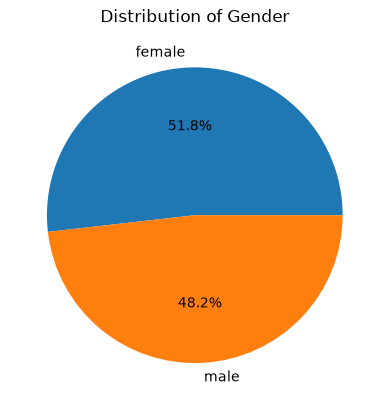

In [67]:
plt.pie(df["gender"].value_counts(), labels=df["gender"].value_counts().index, autopct="%1.1f%%")
plt.title("Distribution of Gender")
plt.show()

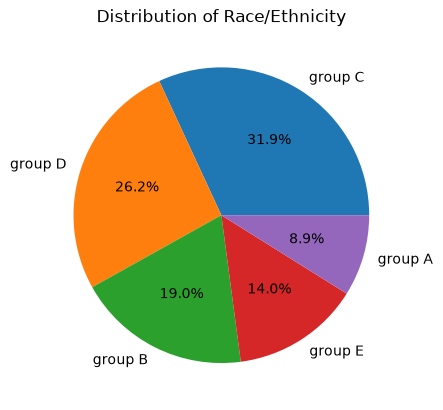

In [68]:
plt.pie(df["race_ethnicity"].value_counts(), labels=df["race_ethnicity"].value_counts().index, autopct="%1.1f%%")
plt.title("Distribution of Race/Ethnicity")
plt.show()

In [69]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


## Distribution of Parental Education

The distribution of parental education levels is examined to understand the composition of the dataset.

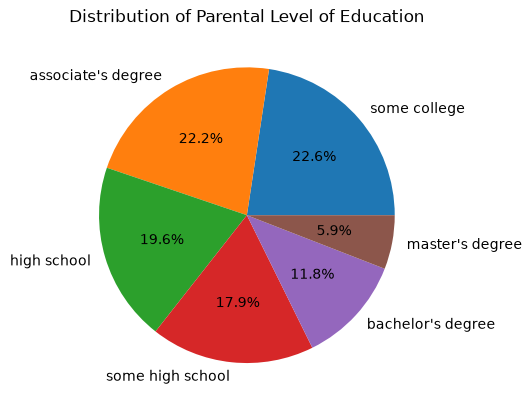

In [70]:
plt.pie(df["parental_level_of_education"].value_counts(), labels = df["parental_level_of_education"].value_counts().index, autopct="%1.1f%%")
plt.title("Distribution of Parental Level of Education")
plt.show()

## Subject Score Distribution and Outlier Analysis

Box plots are used to compare the distributions, spread, medians, and possible outliers of math, reading, and writing scores.

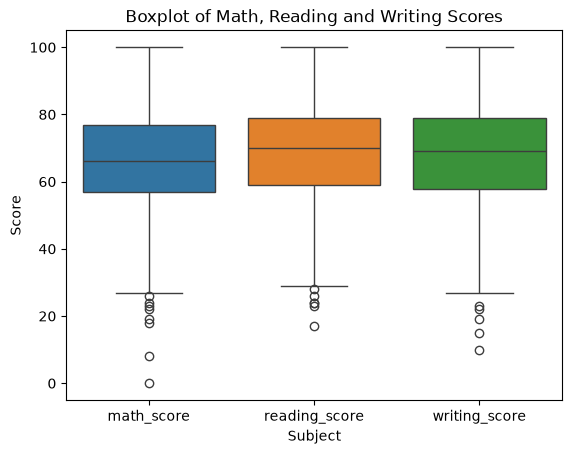

In [71]:
sns.boxplot(data = df[["math_score","reading_score","writing_score"]])
plt.title("Boxplot of Math, Reading and Writing Scores")
plt.xlabel("Subject")
plt.ylabel("Score")
plt.show()

### Observation

- The box plots show the variation in scores across the three subjects.
- Differences in median and spread can be used to compare subject-wise performance.
- Potential outliers represent students with unusually high or low scores.

## Relationship Between Math and Reading Scores

A scatter plot is used to examine the relationship between math and reading scores, with points grouped by gender.

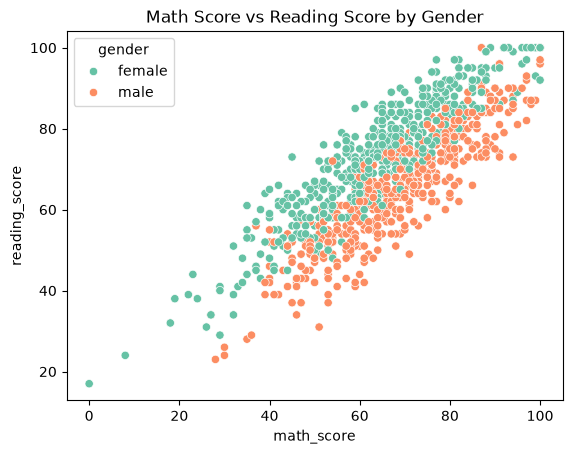

In [72]:
sns.scatterplot(data=df, x="math_score", y="reading_score", hue="gender", palette="Set2")
plt.title("Math Score vs Reading Score by Gender")
plt.show()

### Observation

- Math and reading scores show a positive relationship.
- Students with higher math scores generally tend to have higher reading scores.
- The gender groups show considerable overlap.

## Average Score by Subject

The mean scores of math, reading, and writing are compared using a bar chart.

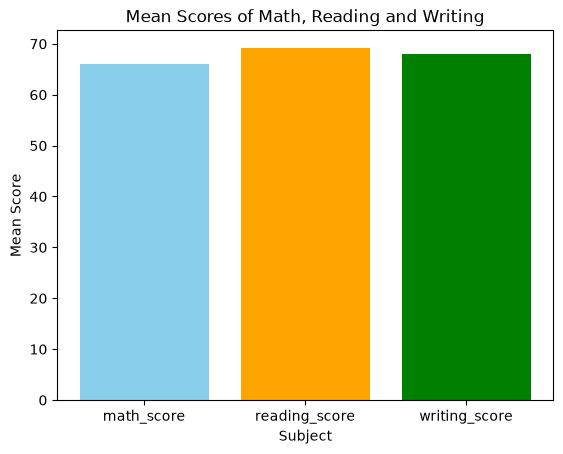

In [73]:
score_means = df[["math_score", "reading_score", "writing_score"]].mean()

plt.bar(score_means.index, score_means.values, color=["skyblue", "orange", "green"])
plt.title("Mean Scores of Math, Reading and Writing")
plt.xlabel("Subject")
plt.ylabel("Mean Score")
plt.show()

## Average Score by Demographic Groups

Average scores are compared across gender and race/ethnicity categories.

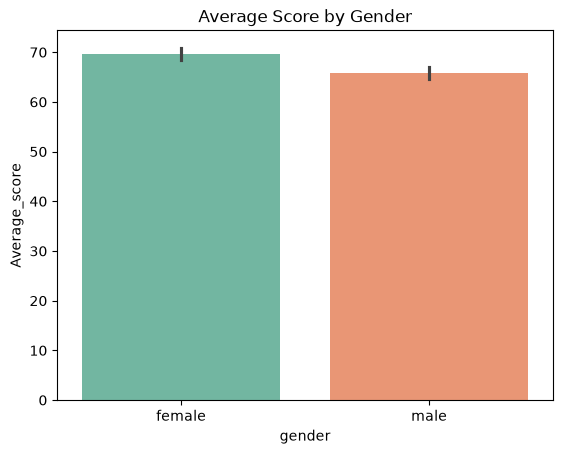

In [74]:
sns.barplot(data = df, x="gender", y="Average_score", palette="Set2", hue="gender")
plt.title("Average Score by Gender")
plt.show()

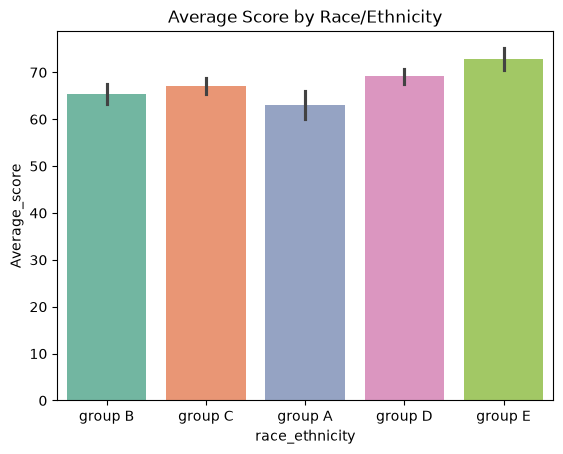

In [75]:
sns.barplot(data=df, x="race_ethnicity", y="Average_score", palette="Set2", hue="race_ethnicity")
plt.title("Average Score by Race/Ethnicity")
plt.show()

## Effect of Test Preparation

The relationship between test preparation course completion and average score is examined using a box plot.

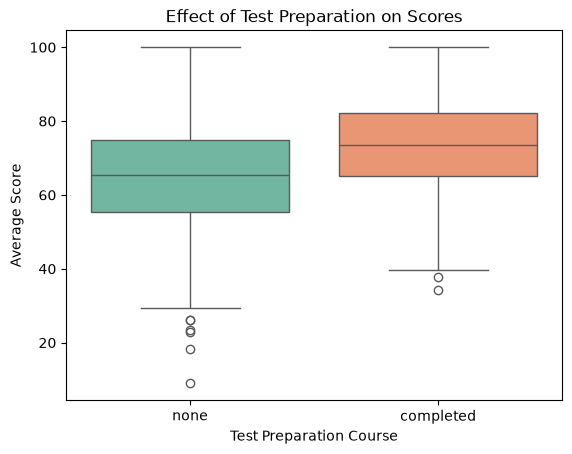

In [76]:
sns.boxplot(
    data=df,
    x="test_preparation_course",
    y="Average_score",
    hue="test_preparation_course",
    palette="Set2",
    legend=False
)
plt.title("Effect of Test Preparation on Scores")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.show()

### Observation

- Students who completed the test preparation course generally show higher average scores.
- Test preparation is positively associated with student performance.

## Average Score by Lunch Type

Average student scores are compared across different lunch categories.

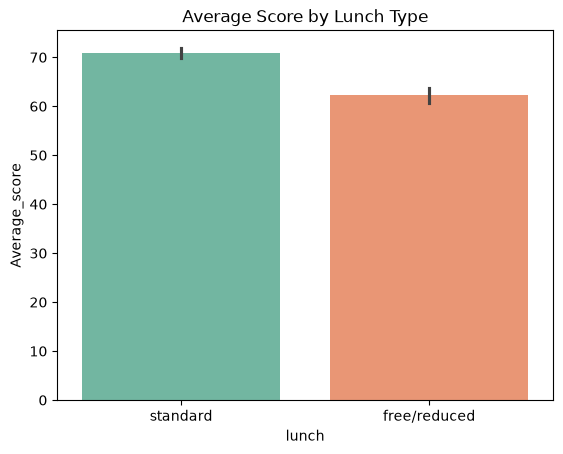

In [77]:
sns.barplot(data=df, x="lunch", y="Average_score", palette="Set2", hue="lunch")
plt.title("Average Score by Lunch Type")
plt.show()

### Observation

- Average scores differ between lunch categories.
- Lunch type may be associated with socioeconomic conditions and academic performance.
- This analysis does not establish a direct causal relationship.

## Correlation Analysis

A correlation heatmap is used to examine relationships among the subject scores, total score, and average score.

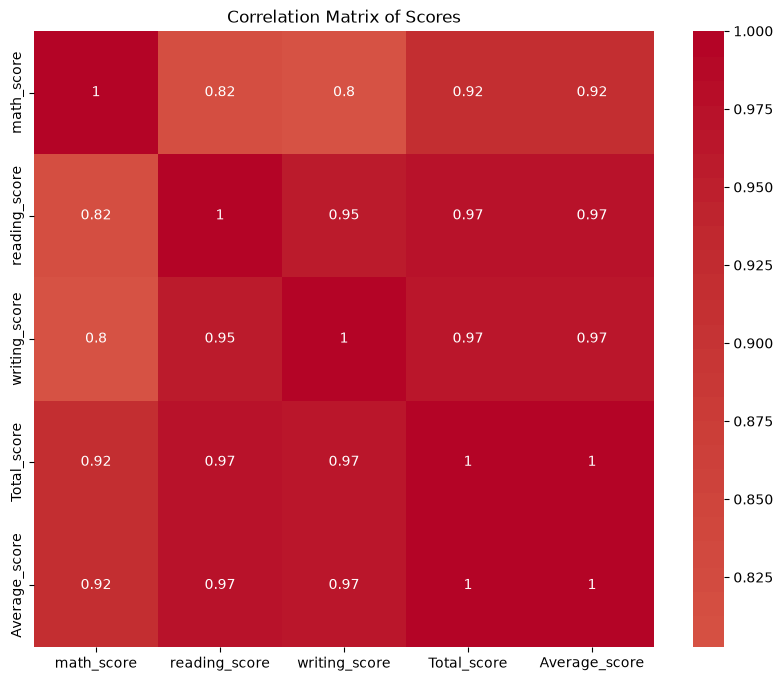

In [78]:
plt.figure(figsize=(10,8))
correlation_matrix = df[["math_score", "reading_score", "writing_score","Total_score","Average_score"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Scores")
plt.show()

### Observation

- Math, reading, and writing scores have strong positive relationships with one another.
- `Total_score` and `Average_score` are strongly correlated with the subject scores because they are calculated from those scores.
- Correlation indicates association and does not prove causation.

## Student Distribution by Parental Education

A count plot shows the number of students in each parental education category.

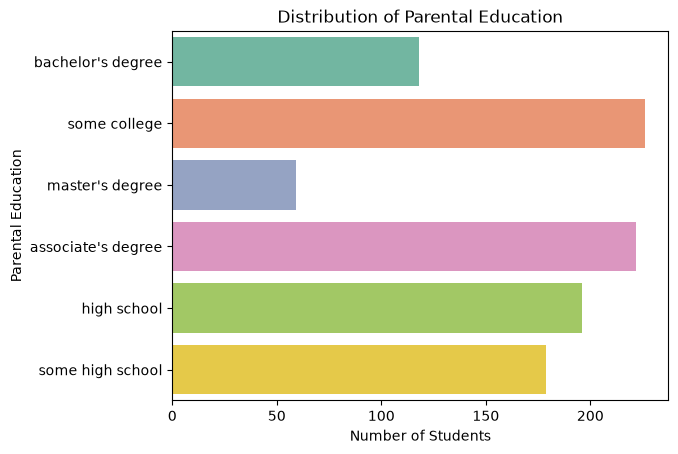

In [79]:
sns.countplot(
    data=df,
    y="parental_level_of_education",
    hue="parental_level_of_education",
    palette="Set2",
    legend=False
)
plt.title("Distribution of Parental Education")
plt.xlabel("Number of Students")
plt.ylabel("Parental Education")
plt.show()

## Average Score by Parental Education

The average student score is compared across parental education categories.

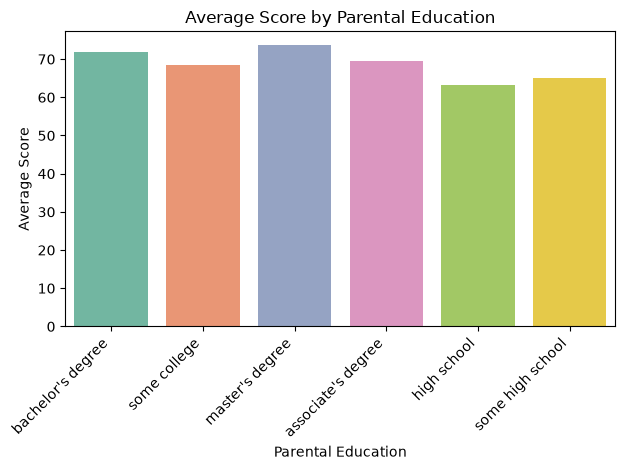

In [80]:
sns.barplot(
    data=df,
    x="parental_level_of_education",
    y="Average_score",
    hue="parental_level_of_education",
    palette="Set2",
    errorbar=None,
    legend=False
)
plt.xticks(rotation=45, ha="right")
plt.title("Average Score by Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()

### Observation

- Average student performance varies across parental education categories.
- Some parental education groups have higher average scores than others.
- This shows an association, not a direct cause-and-effect relationship.
- Other factors, such as lunch type and test preparation, may also influence performance.

## Conclusion

This exploratory analysis examined student performance across subjects and demographic groups. The main findings show relationships between academic scores, test preparation, lunch type, and parental education. These findings can guide further statistical analysis and machine-learning modeling.